In [37]:
import gzip                     
import numpy as np                
import matplotlib.pyplot as plt   
from collections import Counter   

In [38]:
#Read query data
lens = []
with gzip.open('query.bed.gz', 'rt') as f:
    for line in f:
        if line.startswith('#') or not line.strip():
            continue
        parts = line.strip().split()
        start = int(parts[1])
        end = int(parts[2])
        lens.append(end - start)

In [39]:
#Process query frequencies
freqs = Counter(lens)
total = sum(freqs.values())
sizes = np.array(list(freqs.keys()))
counts = np.array(list(freqs.values()))
norm_freqs = counts / total
idx = np.argsort(sizes)
x = sizes[idx]
y = norm_freqs[idx]

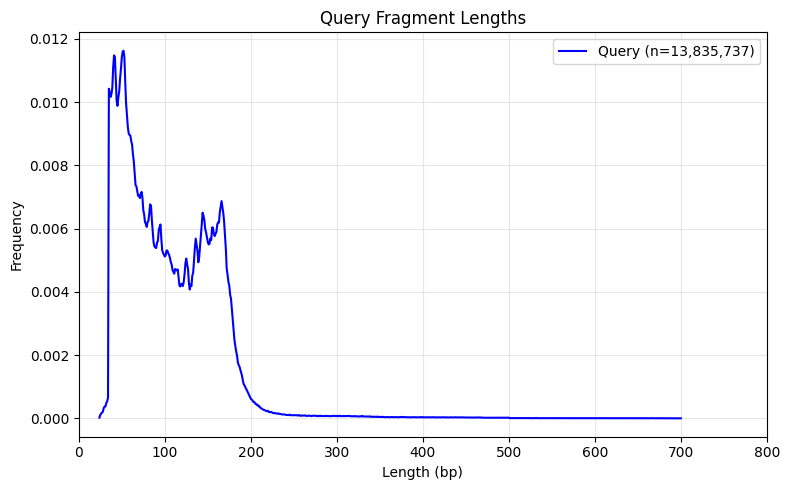

In [40]:
#Plot query distribution
plt.figure(figsize=(8, 5))
plt.plot(x, y, color='blue', label=f'Query (n={total:,})')
plt.xlabel('Length (bp)')
plt.ylabel('Frequency')
plt.title('Query Fragment Lengths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 800)
plt.tight_layout()
plt.show()

In [41]:
#Read reference data
ref_x = []
ref_y = []
with open('reference.hist', 'r') as f:
    for line in f:
        if not line.strip():
            continue
        size, freq = map(float, line.strip().split())
        ref_x.append(int(size))
        ref_y.append(freq)
ref_x = np.array(ref_x)
ref_y = np.array(ref_y)

In [42]:
#Rescale data
sample_n = int(0.3 * len(lens))
scaled = (ref_y / ref_y.sum()) * sample_n
scaled = scaled.astype(int)
curr_freqs = Counter(lens)
new_lens = []
for size, n in zip(ref_x, scaled):
    avail = curr_freqs.get(size, 0)
    if avail == 0:
        continue
    count = min(avail, n)
    new_lens.extend([size] * count)
    curr_freqs[size] -= count

In [43]:
#Process rescaled frequencies
new_freqs = Counter(new_lens)
new_x = np.array(list(new_freqs.keys()))
new_counts = np.array(list(new_freqs.values()))
new_y = new_counts / new_counts.sum()

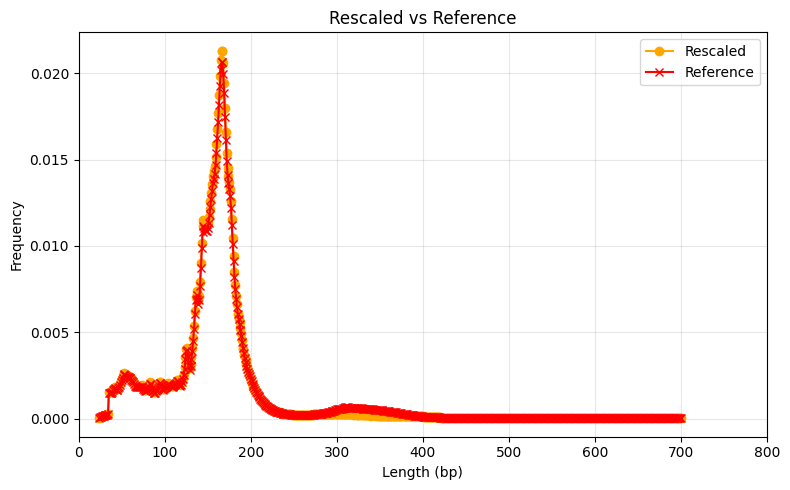

In [44]:
#Plot rescaled vs reference
plt.figure(figsize=(8, 5))
plt.plot(new_x, new_y, 'o-', color='orange', label='Rescaled')
plt.plot(ref_x, ref_y / ref_y.sum(), 'x-', color='red', label='Reference')
plt.xlabel('Length (bp)')
plt.ylabel('Frequency')
plt.title('Rescaled vs Reference')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 800)
plt.tight_layout()
plt.show()


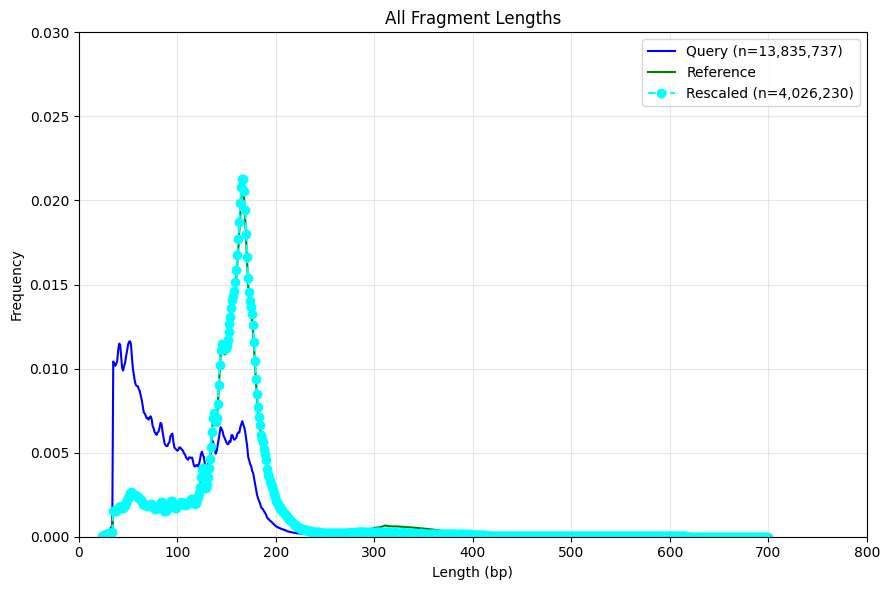

In [45]:
# Cell 9: Plot all distributions
plt.figure(figsize=(9, 6))
plt.plot(x, y, color='blue', label=f'Query (n={len(lens):,})')
plt.plot(ref_x, ref_y / ref_y.sum(), color='green', label='Reference')
plt.plot(new_x, new_y, 'o--', color='cyan', label=f'Rescaled (n={len(new_lens):,})')
plt.xlabel('Length (bp)')
plt.ylabel('Frequency')
plt.title('All Fragment Lengths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 800)
plt.ylim(0, 0.03)
plt.tight_layout()
plt.show()